nstall & Import Libraries

In [9]:
# Install required libraries
!pip install pandas scikit-learn matplotlib seaborn

# Import everything we need
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully")

All libraries imported successfully


Load All 3 Datasets

In [10]:
# Load the three structured log files
hdfs_df    = pd.read_csv('/content/HDFS_2k.log_structured.csv')
openssh_df = pd.read_csv('/content/Linux_2k.log_structured.csv')
linux_df   = pd.read_csv('/content/OpenSSH_2k.log_structured.csv')

# Check what columns each file has
print("HDFS columns:   ", list(hdfs_df.columns))
print("OpenSSH columns:", list(openssh_df.columns))
print("Linux columns:  ", list(linux_df.columns))

print(f"\nHDFS rows:    {len(hdfs_df)}")
print(f"OpenSSH rows: {len(openssh_df)}")
print(f"Linux rows:   {len(linux_df)}")

HDFS columns:    ['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']
OpenSSH columns: ['LineId', 'Month', 'Date', 'Time', 'Level', 'Component', 'PID', 'Content', 'EventId', 'EventTemplate']
Linux columns:   ['LineId', 'Date', 'Day', 'Time', 'Component', 'Pid', 'Content', 'EventId', 'EventTemplate']

HDFS rows:    2000
OpenSSH rows: 2000
Linux rows:   2000


Preview Each Dataset

In [11]:
# See a sample of each dataset
print("=== HDFS Sample ===")
print(hdfs_df[['Content', 'EventId', 'EventTemplate']].head(3).to_string())

print("\n=== OpenSSH Sample ===")
print(openssh_df[['Content', 'EventId', 'EventTemplate']].head(3).to_string())

print("\n=== Linux Sample ===")
print(linux_df[['Content', 'EventId', 'EventTemplate']].head(3).to_string())

=== HDFS Sample ===
                                                                                                                     Content EventId                                                                             EventTemplate
0                                                              PacketResponder 1 for block blk_38865049064139660 terminating     E10                                         PacketResponder <*> for block blk_<*> terminating
1                                                           PacketResponder 0 for block blk_-6952295868487656571 terminating     E10                                         PacketResponder <*> for block blk_<*> terminating
2  BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864      E6  BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>

=== OpenSSH Sample ===
                                                                

Combine All 3 Datasets Into One

In [12]:
# Extract only the columns we need from each dataset
hdfs_content    = hdfs_df[['Content', 'EventId', 'EventTemplate']].copy()
openssh_content = openssh_df[['Content', 'EventId', 'EventTemplate']].copy()
linux_content   = linux_df[['Content', 'EventId', 'EventTemplate']].copy()

# Add a source label so we know where each log came from
hdfs_content['source']    = 'HDFS'
openssh_content['source'] = 'OpenSSH'
linux_content['source']   = 'Linux'

# Combine all three into one single DataFrame
combined_df = pd.concat(
    [hdfs_content, openssh_content, linux_content],
    ignore_index=True
)

print(f"Total combined logs: {len(combined_df)}")
print("\nLogs per source:")
print(combined_df['source'].value_counts())
print("\nFirst 5 rows:")
combined_df.head()

Total combined logs: 6000

Logs per source:
source
HDFS       2000
OpenSSH    2000
Linux      2000
Name: count, dtype: int64

First 5 rows:


,Content,EventId,EventTemplate,source
0,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS
1,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS
2,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...,HDFS
3,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS
4,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating,HDFS


Label the Data (Anomaly vs Normal)

In [13]:
# Define keywords that indicate suspicious or anomalous activity
anomaly_keywords = [
    'failed', 'failure', 'invalid', 'error', 'refused',
    'unauthorized', 'denied', 'attack', 'break-in',
    'illegal', 'bad', 'corrupt', 'lost', 'exception',
    'unknown', 'wrong', 'breach', 'suspicious',
    'timeout', 'abort', 'critical', 'fatal'
]

# Function to label each log entry
def label_log(content):
    if pd.isna(content):
        return 0
    content_lower = str(content).lower()
    for keyword in anomaly_keywords:
        if keyword in content_lower:
            return 1  # Anomaly
    return 0           # Normal

# Apply labeling to every row
combined_df['label'] = combined_df['Content'].apply(label_log)
combined_df['label_name'] = combined_df['label'].map({0: 'Normal', 1: 'Anomaly'})

print("Label distribution:")
print(combined_df['label_name'].value_counts())
print(f"\nAnomaly rate: {combined_df['label'].mean() * 100:.1f}%")

Label distribution:
label_name
Normal     3513
Anomaly    2487
Name: count, dtype: int64

Anomaly rate: 41.4%


Visualize Label Distribution

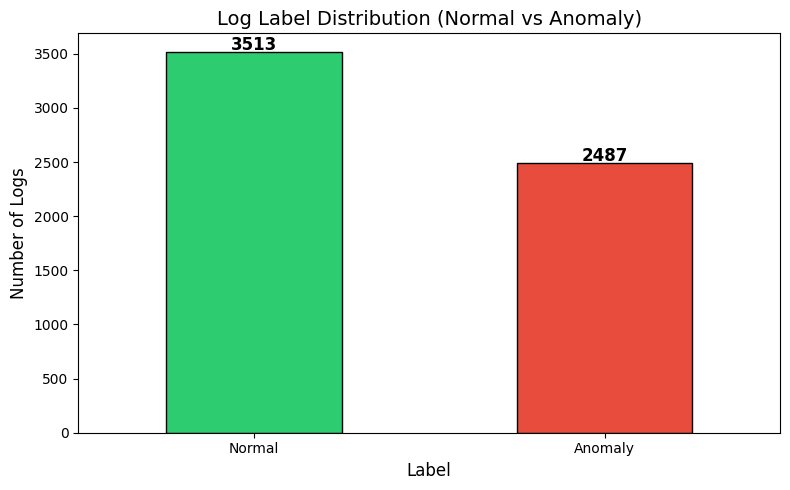

Chart saved!


In [14]:
# Bar chart of Normal vs Anomaly
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']

combined_df['label_name'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Log Label Distribution (Normal vs Anomaly)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Number of Logs', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(combined_df['label_name'].value_counts()):
    plt.text(i, v + 20, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

Visualize Distribution Per Source

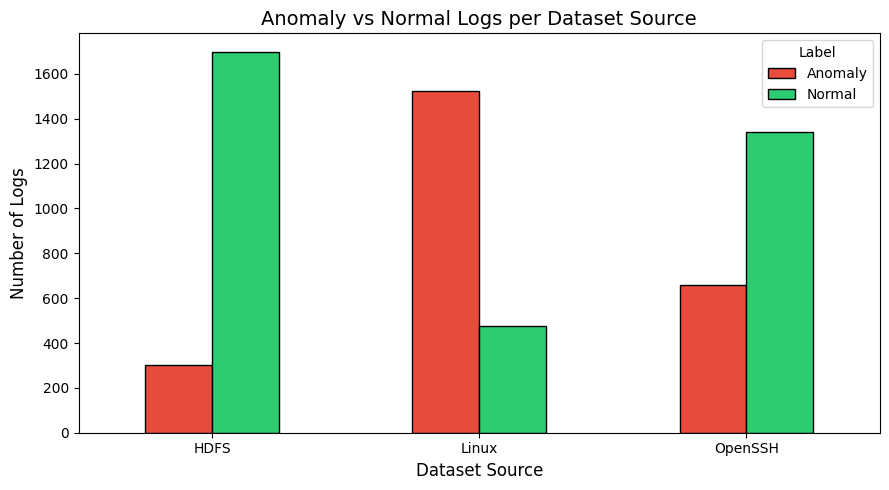

In [15]:
# Stacked bar chart - anomaly vs normal per dataset source
source_label = combined_df.groupby(['source', 'label_name']).size().unstack()

source_label.plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71'],
    figsize=(9, 5),
    edgecolor='black'
)

plt.title('Anomaly vs Normal Logs per Dataset Source', fontsize=14)
plt.xlabel('Dataset Source', fontsize=12)
plt.ylabel('Number of Logs', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.savefig('source_distribution.png', dpi=150)
plt.show()

Clean and Normalize the Text

In [16]:
# Text cleaning function
def clean_log(text):
    if pd.isna(text):
        return ""
    text = str(text)

    # Replace IP addresses with a token
    text = re.sub(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', 'IP_ADDR', text)

    # Replace port numbers with a token
    text = re.sub(r'\bport\s+\d+', 'port PORT_NUM', text)

    # Replace HDFS block IDs with a token
    text = re.sub(r'blk_-?\d+', 'BLOCK_ID', text)

    # Remove process IDs like [24200]
    text = re.sub(r'\[\d+\]', '', text)

    # Replace hex values
    text = re.sub(r'0x[0-9a-fA-F]+', 'HEX_VAL', text)

    # Replace long standalone numbers
    text = re.sub(r'\b\d{5,}\b', 'NUM', text)

    # Replace domain/hostnames
    text = re.sub(r'\b[a-zA-Z0-9\-]+\.[a-zA-Z]{2,}\b', 'HOSTNAME', text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s_]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning to all logs
combined_df['cleaned_content'] = combined_df['Content'].apply(clean_log)

# Show before and after examples
print("BEFORE vs AFTER Cleaning Examples:\n")
examples = combined_df[['Content', 'cleaned_content', 'source']].sample(5, random_state=42)
for _, row in examples.iterrows():
    print(f"Source:  {row['source']}")
    print(f"BEFORE:  {row['Content']}")
    print(f"AFTER:   {row['cleaned_content']}")

BEFORE vs AFTER Cleaning Examples:

Source:  HDFS
BEFORE:  Received block blk_-4775386099844009890 of size 67108864 from /10.251.107.19
AFTER:   received block block_id of size num from ip_addr
Source:  OpenSSH
BEFORE:  0MB HIGHMEM available.
AFTER:   mb highmem available
Source:  HDFS
BEFORE:  Receiving block blk_-8227485321105019293 src: /10.251.195.33:56999 dest: /10.251.195.33:50010
AFTER:   receiving block block_id src ip_addr num dest ip_addr num
Source:  OpenSSH
BEFORE:  User unknown timed out after 900 seconds at Sat Jun 18 02:23:10 2005
AFTER:   user unknown timed out after seconds at sat jun
Source:  Linux
BEFORE:  Failed password for root from 183.62.140.253 port 55676 ssh2
AFTER:   failed password for root from ip_addr port port_num ssh


Check for Empty/Null Values After Cleaning

In [17]:
print("Null values check:")
print(combined_df[['Content', 'cleaned_content', 'label']].isnull().sum())

print(f"\nEmpty cleaned logs: {(combined_df['cleaned_content'] == '').sum()}")
print(f"Total usable logs:  {(combined_df['cleaned_content'] != '').sum()}")

# Drop any rows where cleaned content is empty
combined_df = combined_df[combined_df['cleaned_content'] != ''].reset_index(drop=True)
print(f"\nFinal dataset size after cleanup: {len(combined_df)} rows")

Null values check:
Content            0
cleaned_content    0
label              0
dtype: int64

Empty cleaned logs: 0
Total usable logs:  6000

Final dataset size after cleanup: 6000 rows


TF-IDF Vectorization

In [18]:
# Convert cleaned text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2
)

# Fit and transform the cleaned text
X = vectorizer.fit_transform(combined_df['cleaned_content'])
y = combined_df['label']

print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"  → {X.shape[0]} log entries")
print(f"  → {X.shape[1]} features (words/bigrams)")

# Show top features
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample TF-IDF features (first 30):")
print(list(feature_names[:30]))

TF-IDF Matrix Shape: (6000, 500)
  → 6000 log entries
  → 500 features (words/bigrams)

Sample TF-IDF features (first 30):
['_m_', '_m_ part', '_r_', '_r_ part', '_task_', '_task_ _m_', '_task_ _r_', '_temporary', '_temporary _task_', 'abnormally', 'abnormally with', 'abort', 'acpi', 'added', 'added to', 'admin', 'admin from', 'admin preauth', 'alert', 'alert exited', 'anonymous', 'anonymous from', 'ask', 'ask ip_addr', 'at', 'at fri', 'at mon', 'at sat', 'at sun', 'at thu']


Save All Processed Files

In [19]:
# Save the full combined cleaned dataset
combined_df[['Content', 'cleaned_content', 'EventId',
             'EventTemplate', 'source', 'label', 'label_name']].to_csv(
    'cleaned_logs_combined.csv', index=False
)

# Save individual source files
for source in ['HDFS', 'OpenSSH', 'Linux']:
    subset = combined_df[combined_df['source'] == source]
    subset[['Content', 'cleaned_content', 'label', 'label_name']].to_csv(
        f'cleaned_{source.lower()}_logs.csv', index=False
    )
    print(f"Saved: cleaned_{source.lower()}_logs.csv ({len(subset)} rows)")

print("\nSaved: cleaned_logs_combined.csv")
print("All files saved successfully!")

Saved: cleaned_hdfs_logs.csv (2000 rows)
Saved: cleaned_openssh_logs.csv (2000 rows)
Saved: cleaned_linux_logs.csv (2000 rows)

Saved: cleaned_logs_combined.csv
All files saved successfully!


Parse cloud_auth.log

In [21]:
def parse_cloud_log(filepath, source_name):
    rows = []
    with open(filepath, 'r', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Format: 2026-04-05T11:07:34.935497+00:00 hostname service[pid]: message
            match = re.match(
                r'(\S+)\s+(\S+)\s+([\w\-\.]+)(?:\[\d+\])?\s*:\s*(.*)', line
            )
            if match:
                timestamp, hostname, service, message = match.groups()
                rows.append({
                    'timestamp': timestamp,
                    'hostname': hostname,
                    'service': service,
                    'message': message,
                    'raw_log': line,
                    'source': source_name
                })
    return pd.DataFrame(rows)

auth_df   = parse_cloud_log('cloud_auth.log',   'cloud_auth')
syslog_df = parse_cloud_log('cloud_syslog.log', 'cloud_syslog')

print(f"cloud_auth.log  → {len(auth_df)} rows")
print(f"cloud_syslog.log→ {len(syslog_df)} rows")
auth_df.head(3)

cloud_auth.log  → 125 rows
cloud_syslog.log→ 1129 rows


,timestamp,hostname,service,message,raw_log,source
0,2026-04-05T11:07:34.935497+00:00,ip-172-31-75-209,useradd,"new group: name=ubuntu, GID=1000",2026-04-05T11:07:34.935497+00:00 ip-172-31-75-...,cloud_auth
1,2026-04-05T11:07:34.935503+00:00,ip-172-31-75-209,useradd,"new user: name=ubuntu, UID=1000, GID=1000, hom...",2026-04-05T11:07:34.935503+00:00 ip-172-31-75-...,cloud_auth
2,2026-04-05T11:07:34.935508+00:00,ip-172-31-75-209,useradd,add 'ubuntu' to group 'adm',2026-04-05T11:07:34.935508+00:00 ip-172-31-75-...,cloud_auth


 Label cloud logs

In [22]:
# Keywords that indicate anomalous/suspicious activity
ANOMALY_KEYWORDS = [
    'invalid user', 'failed', 'error', 'denied', 'unauthorized',
    'connection closed by invalid', 'break-in', 'illegal',
    'accessdenied', 'no valid credentials', 'failed to connect'
]

def label_cloud_log(message):
    msg_lower = str(message).lower()
    for kw in ANOMALY_KEYWORDS:
        if kw in msg_lower:
            return 1  # anomaly
    return 0  # normal

auth_df['label']   = auth_df['message'].apply(label_cloud_log)
syslog_df['label'] = syslog_df['message'].apply(label_cloud_log)

print("=== cloud_auth.log labels ===")
print(auth_df['label'].value_counts().rename({0:'Normal', 1:'Anomaly'}))
print("\n=== cloud_syslog.log labels ===")
print(syslog_df['label'].value_counts().rename({0:'Normal', 1:'Anomaly'}))

=== cloud_auth.log labels ===
label
Normal     65
Anomaly    60
Name: count, dtype: int64

=== cloud_syslog.log labels ===
label
Normal     1109
Anomaly      20
Name: count, dtype: int64


Clean and normalize cloud logs (same pipeline as benchmark)

In [23]:
def normalize_log(text):
    text = str(text).lower()
    text = re.sub(r'\b\d{1,3}(?:\.\d{1,3}){3}\b', 'ip_addr', text)   # IP addresses
    text = re.sub(r'\bport\s+\d+\b', 'port_num', text)                  # Port numbers
    text = re.sub(r'\bpid\s*=?\s*\d+\b', '', text)                      # PIDs
    text = re.sub(r'\buid=\d+\b', '', text)                              # UIDs
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}T[\d:\.+]+\b', '', text)        # Timestamps
    text = re.sub(r'\[[\d]+\]', '', text)                                # Process IDs in brackets
    text = re.sub(r'[^a-z\s_]', ' ', text)                              # Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()                            # Extra spaces
    return text

auth_df['cleaned_log']   = auth_df['message'].apply(normalize_log)
syslog_df['cleaned_log'] = syslog_df['message'].apply(normalize_log)

print("Sample cleaned auth log:")
print(auth_df[['message','cleaned_log','label']].head(5).to_string())

Sample cleaned auth log:
                                                                                    message                                                         cleaned_log  label
0                                                          new group: name=ubuntu, GID=1000                                           new group name ubuntu gid      0
1  new user: name=ubuntu, UID=1000, GID=1000, home=/home/ubuntu, shell=/bin/bash, from=none  new user name ubuntu gid home home ubuntu shell bin bash from none      0
2                                                               add 'ubuntu' to group 'adm'                                             add ubuntu to group adm      0
3                                                             add 'ubuntu' to group 'cdrom'                                           add ubuntu to group cdrom      0
4                                                              add 'ubuntu' to group 'sudo'                                            add u

Merge with your existing benchmark data and save

In [24]:
cloud_df = pd.concat([auth_df, syslog_df], ignore_index=True)
cloud_df = cloud_df[['cleaned_log', 'label', 'source']]

# combined_df is your existing 6,000-row benchmark dataframe
full_df = pd.concat(
    [
        combined_df[['cleaned_content','label','source']].rename(columns={'cleaned_content': 'cleaned_log'}),
        cloud_df
    ],
    ignore_index=True
)

full_df.to_csv('full_dataset_final.csv', index=False)

print(f"Total logs: {len(full_df)}")
print(full_df['label'].value_counts().rename({0:'Normal', 1:'Anomaly'}))
print("\nBy source:")
print(full_df['source'].value_counts())

Total logs: 7254
label
Normal     4687
Anomaly    2567
Name: count, dtype: int64

By source:
source
HDFS            2000
OpenSSH         2000
Linux           2000
cloud_syslog    1129
cloud_auth       125
Name: count, dtype: int64
